# Problem Statement

Develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimise the risk of losing money while lending to customers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

| Column                     | Description |
|----------------------------|-------------|
| `client_id`                | Unique identifier assigned to each customer/client record. |
| `name`                     | Full name of the client. |
| `age`                      | Age of the client in years. |
| `location_id`              | Identifier representing the client's geographic location or branch region. |
| `joined_bank`              | Date on which the client joined the bank (used to calculate tenure/cohort). |
| `banking_contact`          | Name or ID of the bank representative/relationship manager assigned to the client. |
| `nationality`              | Nationality of the client. |
| `occupation`               | Client's occupation or job category. |
| `fee_structure`            | The type of fee plan or pricing tier the client is on (e.g., flat fee, percentage-based). |
| `loyalty_classification`   | Tier or category representing the client's loyalty status with the bank (e.g., Platinum, Gold, Silver). |
| `estimated_income`         | Estimated annual income of the client. |
| `superannuation_savings`   | Total amount the client has saved in their superannuation (retirement) account. |
| `amount_of_credit_cards`   | Number of credit cards the client holds. |
| `credit_card_balance`      | Outstanding balance owed across the client's credit card(s). |
| `bank_loans`                | Total value of loans the client currently holds with the bank. |
| `bank_deposits`             | Total value of deposits the client holds with the bank. |
| `checking_accounts`        | Balance held in the client's checking (transactional) account(s). |
| `saving_accounts`          | Balance held in the client's savings account(s). |
| `foreign_currency_account` | Balance held in foreign currency-denominated account(s). |
| `business_lending`         | Total value of business-related loans/credit extended to the client. |
| `properties_owned`         | Number of properties owned by the client. |
| `risk_weighting`           | A score or category representing the client's assessed credit/lending risk level. |
| `brid`                     | Likely an internal banking relationship/reference ID (Bank Relationship ID). |
| `genderid`                 | Coded identifier representing the client's gender. |
| `iaid`                     | Likely an internal account or identifier code (e.g., Internal Account ID). |

In [2]:
df = pd.read_csv('Banking.csv')
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [3]:
#size of dataset
df.shape

(3000, 25)

In [4]:
#columns information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [5]:
#change to date data type
df['Joined Bank'] = pd.to_datetime(
    df['Joined Bank'],
    format='%d-%m-%Y'
)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Client ID                 3000 non-null   object        
 1   Name                      3000 non-null   object        
 2   Age                       3000 non-null   int64         
 3   Location ID               3000 non-null   int64         
 4   Joined Bank               3000 non-null   datetime64[ns]
 5   Banking Contact           3000 non-null   object        
 6   Nationality               3000 non-null   object        
 7   Occupation                3000 non-null   object        
 8   Fee Structure             3000 non-null   object        
 9   Loyalty Classification    3000 non-null   object        
 10  Estimated Income          3000 non-null   float64       
 11  Superannuation Savings    3000 non-null   float64       
 12  Amount of Credit Car

In [7]:
#change column name to lower case
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [8]:
df.head()

,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,...,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [9]:
df.isna().sum()

client_id                   0
name                        0
age                         0
location_id                 0
joined_bank                 0
banking_contact             0
nationality                 0
occupation                  0
fee_structure               0
loyalty_classification      0
estimated_income            0
superannuation_savings      0
amount_of_credit_cards      0
credit_card_balance         0
bank_loans                  0
bank_deposits               0
checking_accounts           0
saving_accounts             0
foreign_currency_account    0
business_lending            0
properties_owned            0
risk_weighting              0
brid                        0
genderid                    0
iaid                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df_new = df.copy()

In [12]:
#Map gender column

df_new['genderid'] = df_new['genderid'].map({1 : 'male', 2 : 'female'})

#Map brid column
df_new['brid'] = df_new['brid'].map({1 : 'retail', 2 : 'institutional', 3 : 'private bank', 4 : 'commercial'})

In [13]:
df_new.head()

,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,...,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,retail,male,1
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,institutional,male,2
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,private bank,female,3
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,commercial,male,4
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,retail,female,5


In [14]:
df_new.describe().T

,count,mean,min,25%,50%,75%,max,std
age,3000.0,51.039667,17.0,34.0,51.0,69.0,85.0,19.85476
location_id,3000.0,21563.323,12.0,10803.5,21129.5,32054.5,43369.0,12462.273017
joined_bank,3000,2010-08-15 00:03:21.600000,1995-01-03 00:00:00,2004-04-01 18:00:00,2011-02-18 00:00:00,2017-12-24 06:00:00,2021-12-31 00:00:00,NaN
estimated_income,3000.0,171305.034263,15919.48,82906.595,142313.48,242290.305,522330.26,111935.808209
superannuation_savings,3000.0,25531.599673,1482.03,12513.775,22357.355,35464.74,75963.9,16259.95077
amount_of_credit_cards,3000.0,1.463667,1.0,1.0,1.0,2.0,3.0,0.676387
credit_card_balance,3000.0,3176.206943,1.17,1236.63,2560.805,4522.6325,13991.99,2497.094709
bank_loans,3000.0,591386.155487,0.0,239628.1375,479793.4,825813.0375,2667556.66,457557.036334
bank_deposits,3000.0,671560.193923,0.0,204400.375,463316.46,942754.63,3890598.08,645716.856875
checking_accounts,3000.0,321092.949127,0.0,119947.53,242815.655,434874.9375,1969923.08,282079.553893


## Univariate Analysis

In [15]:
bins = [0, 100000, 300000, float('inf')]
labels = ['low','mid','high']

df_new['income_band'] = pd.cut(df['estimated_income'], bins=bins, labels=labels, right=False)

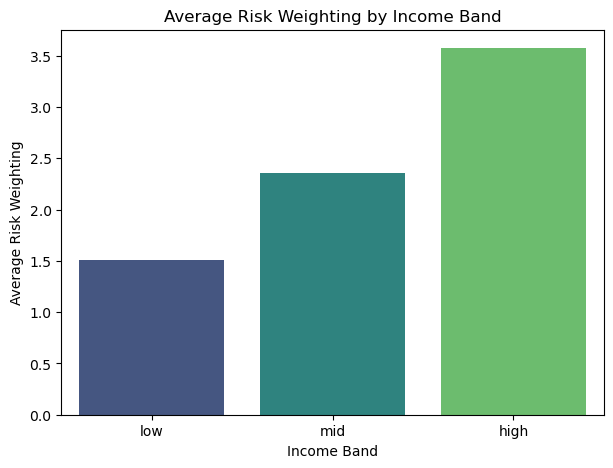

In [16]:
# Calculate average risk_weighting per Income Band

# Fix 1: add observed=False (or True) explicitly to groupby
risk_by_income = df_new.groupby('income_band', observed=False)['risk_weighting'].mean().reindex(['low', 'mid', 'high'])

plt.figure(figsize=(7,5))

# Fix 2: assign x to hue and turn off the legend, instead of using palette directly
sns.barplot(
    x=risk_by_income.index,
    y=risk_by_income.values,
    hue=risk_by_income.index,
    palette='viridis',
    legend=False
)

plt.title('Average Risk Weighting by Income Band')
plt.xlabel('Income Band')
plt.ylabel('Average Risk Weighting')
plt.show()

In [17]:
cat_cols = df_new[['brid','genderid','amount_of_credit_cards','nationality','occupation','fee_structure','loyalty_classification','properties_owned','risk_weighting','iaid','income_band']].columns

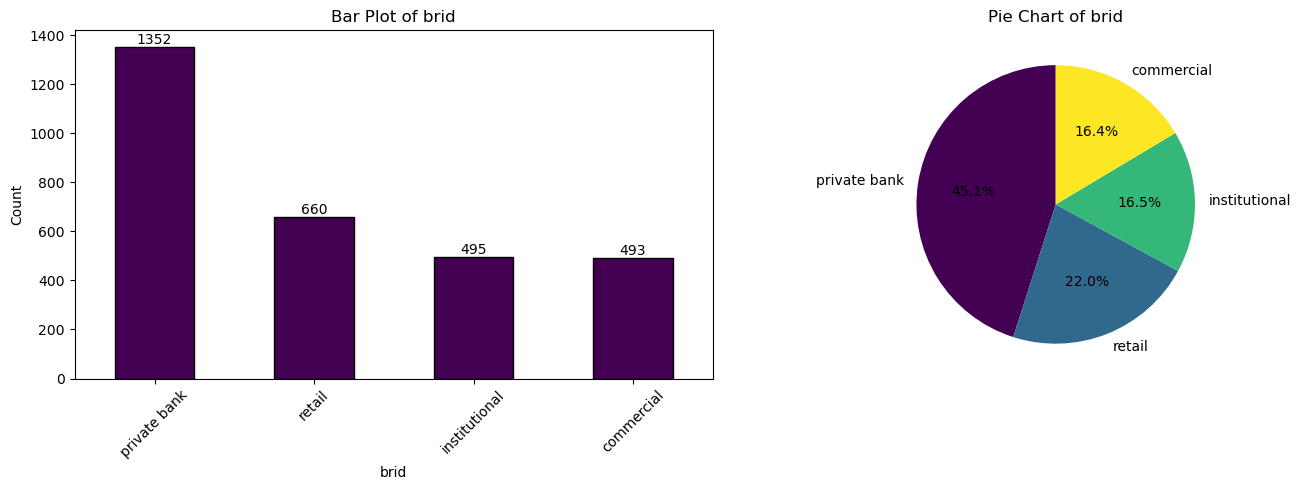

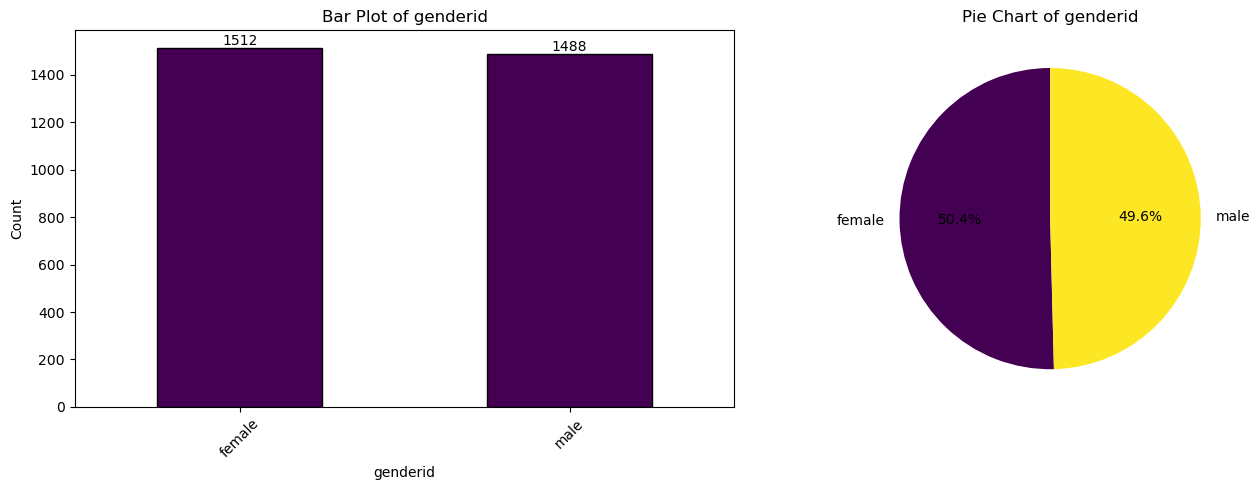

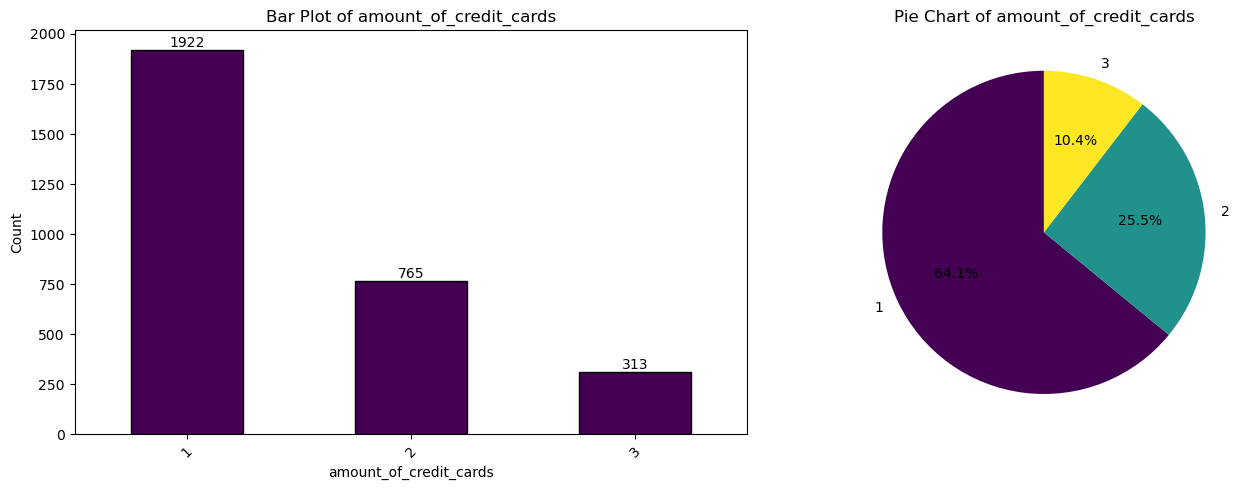

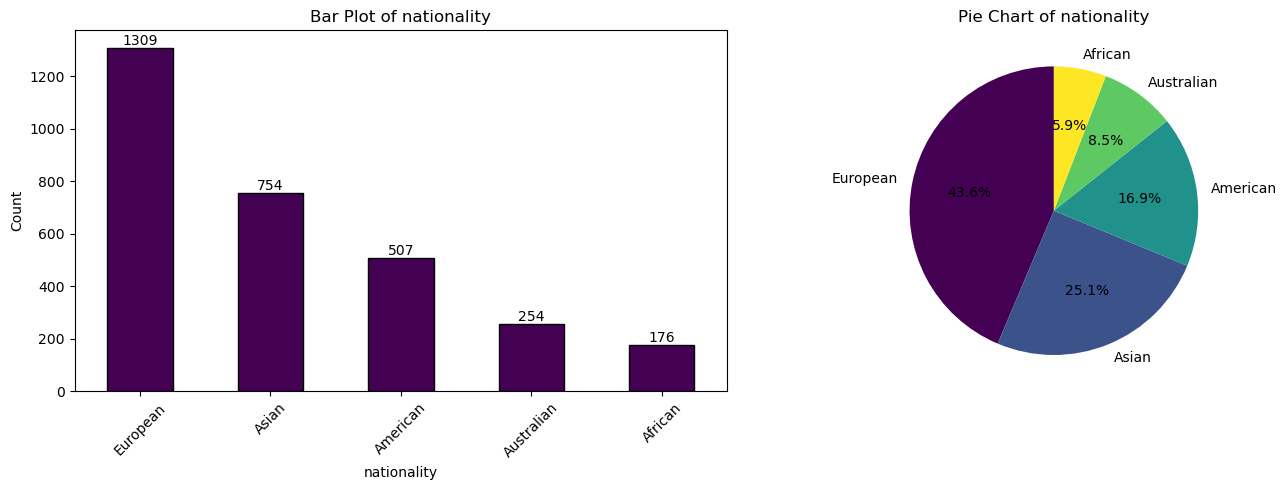

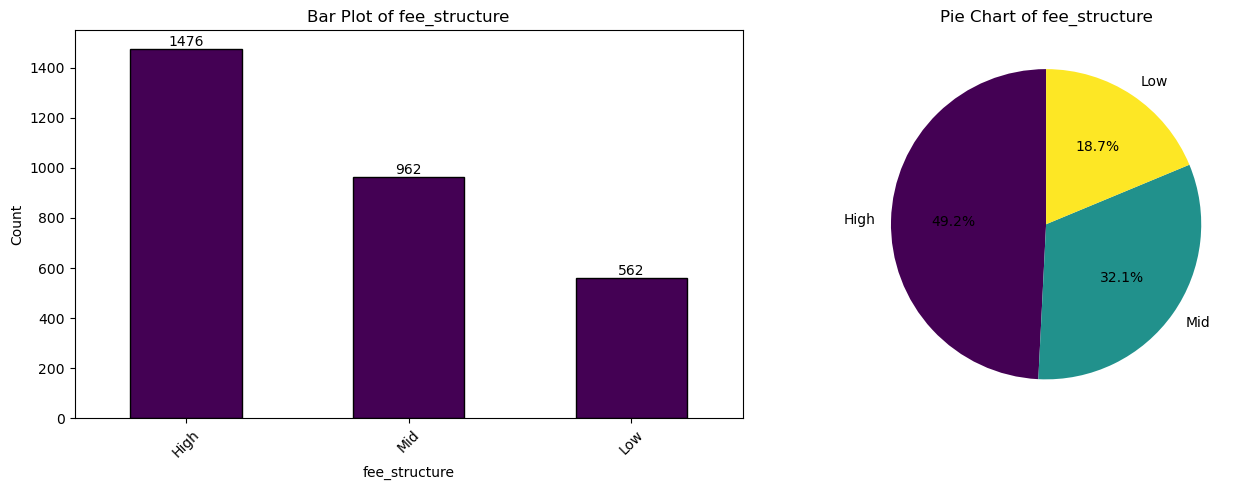

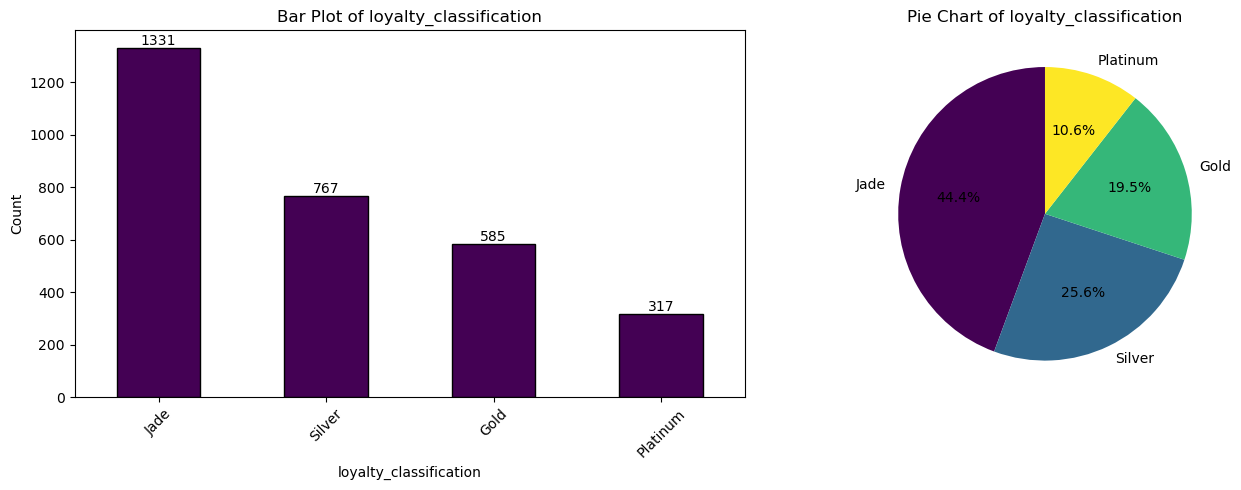

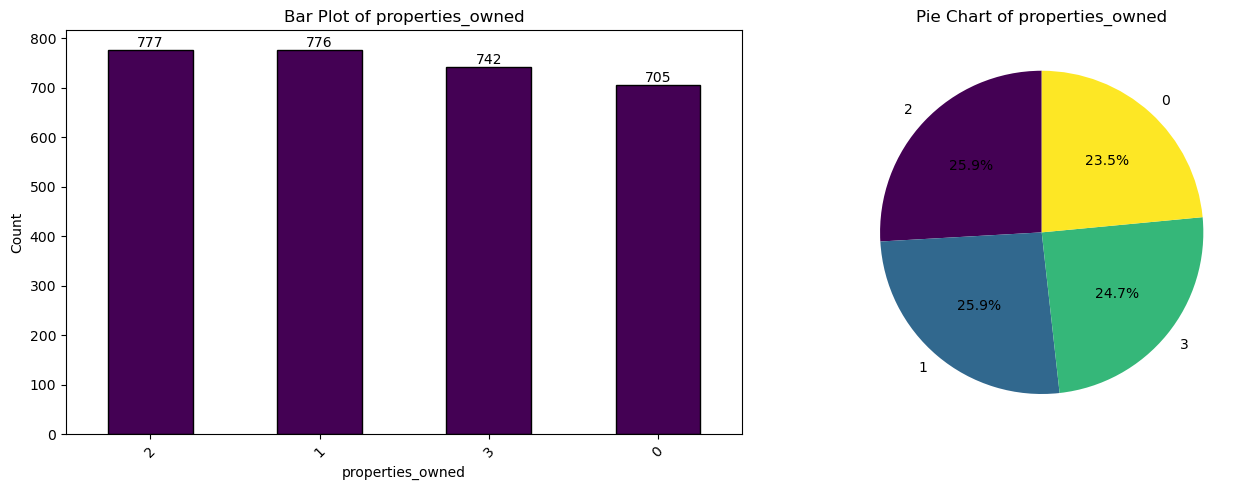

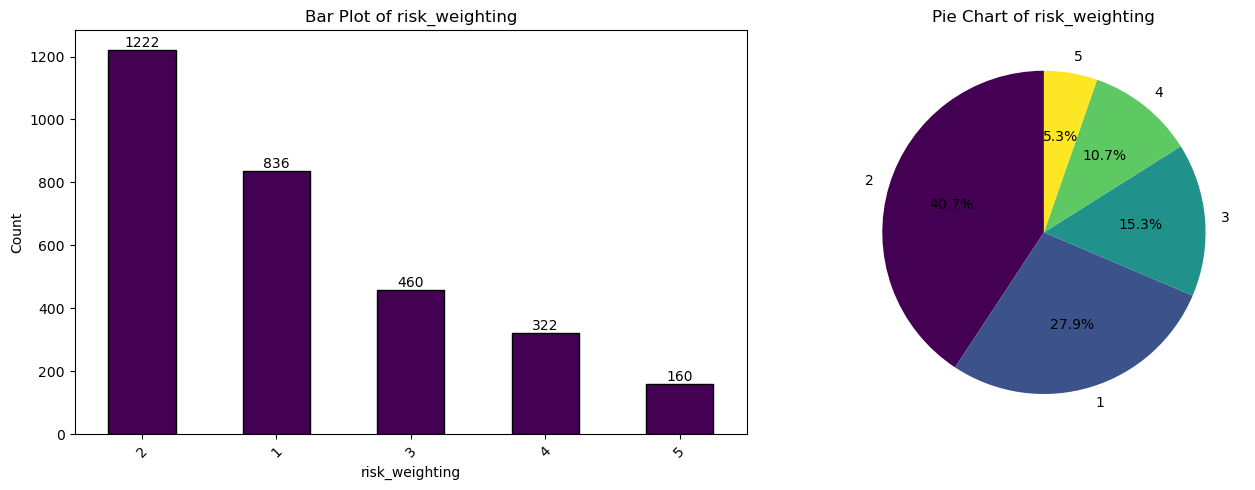

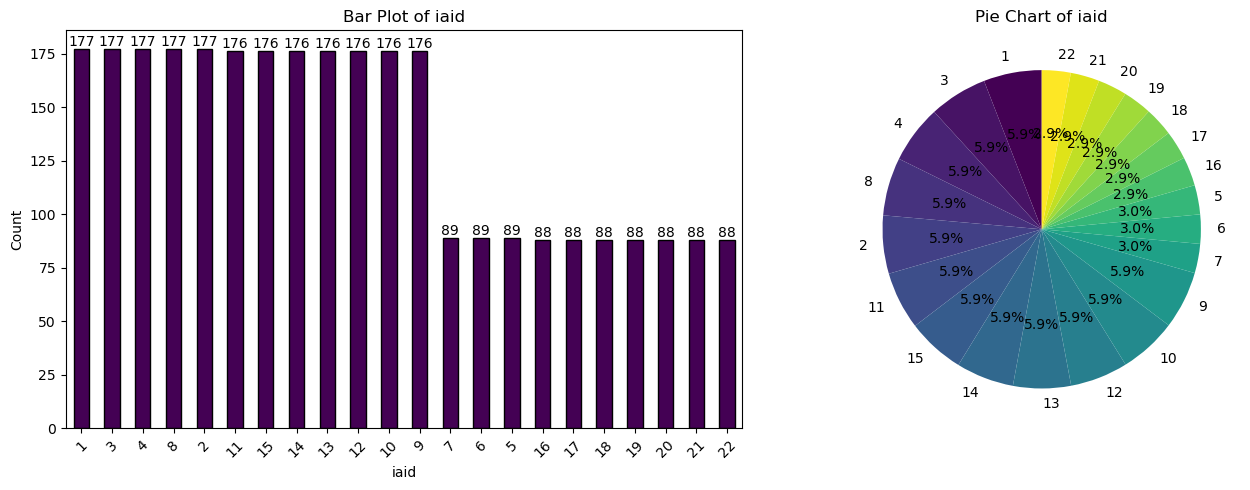

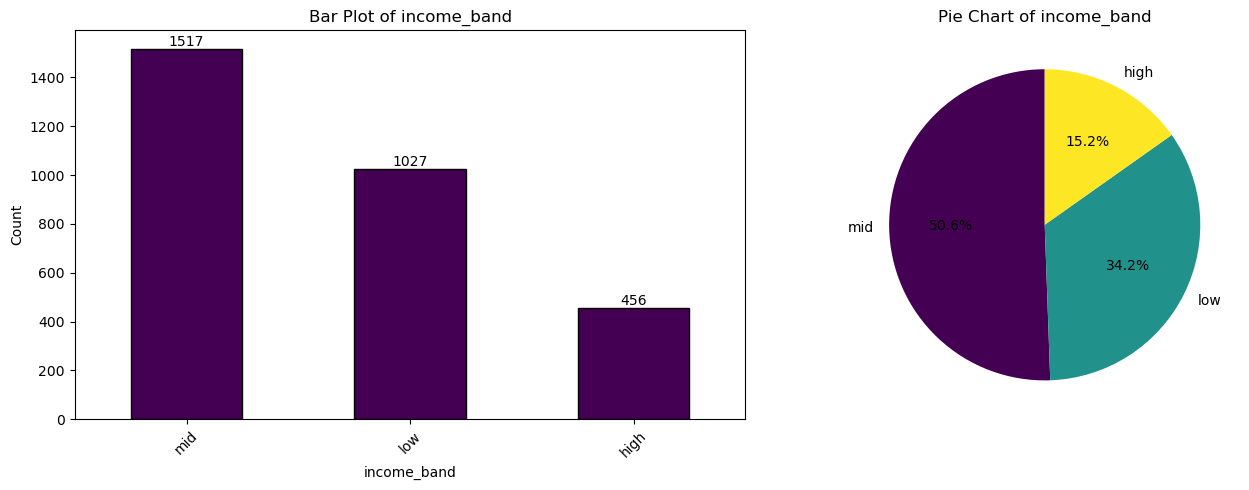

In [18]:
categorical_cols = [
    'brid', 'genderid', 'amount_of_credit_cards', 'nationality',
    'fee_structure', 'loyalty_classification',
    'properties_owned', 'risk_weighting', 'iaid', 'income_band'
]

for col in categorical_cols:
    # Count the occurrences of each category
    counts = df_new[col].value_counts()

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------------- Bar Plot ----------------
    counts.plot(
        kind='bar',
        ax=axes[0],
        colormap='viridis',
        edgecolor='black'
    )
    axes[0].set_title(f'Bar Plot of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    # Add count labels on bars
    for container in axes[0].containers:
        axes[0].bar_label(container)

    # ---------------- Pie Chart ----------------
    counts.plot(
        kind='pie',
        ax=axes[1],
        autopct='%1.1f%%',
        startangle=90,
        colormap = 'viridis'
    )
    axes[1].set_title(f'Pie Chart of {col}')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

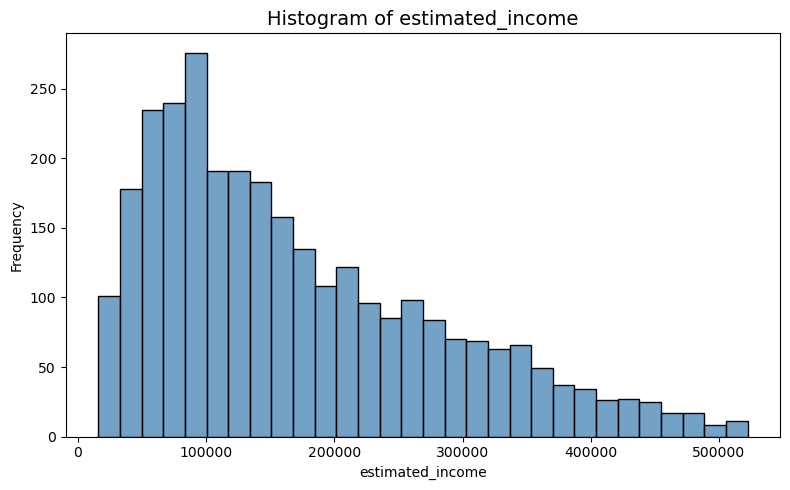

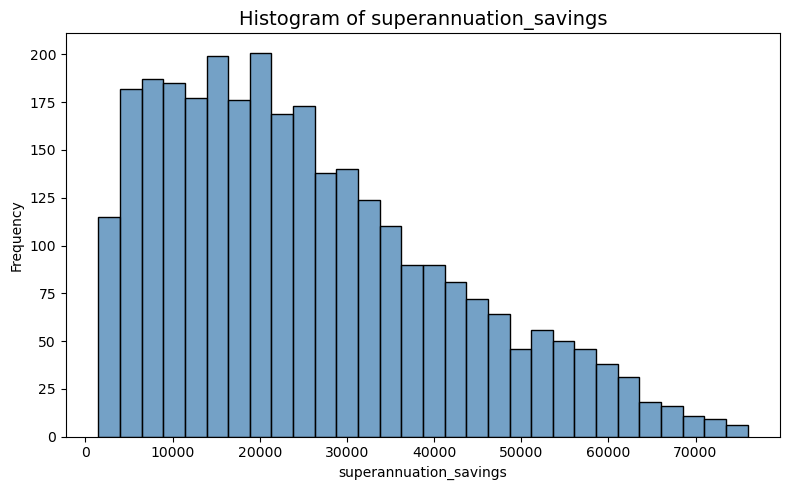

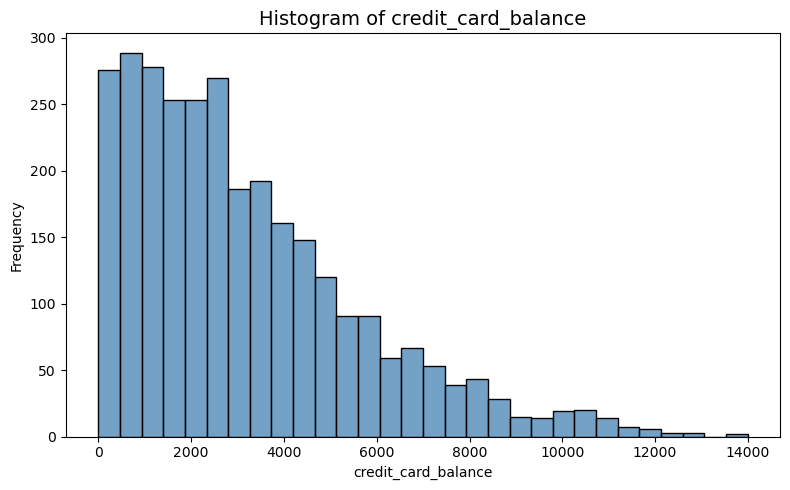

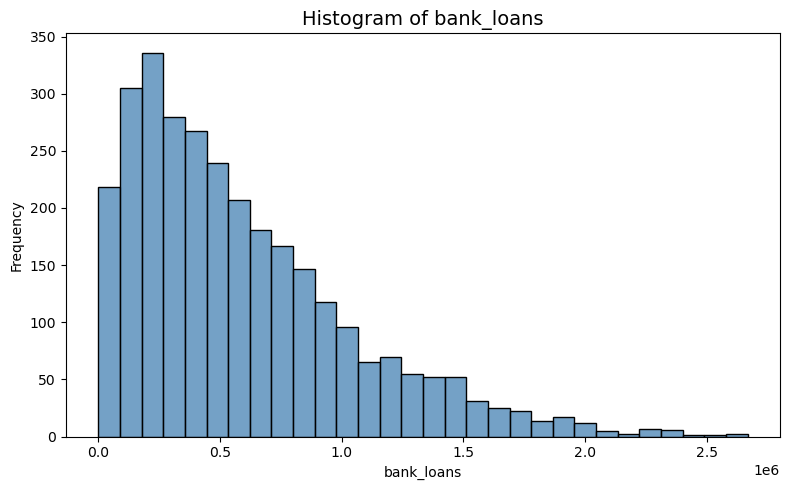

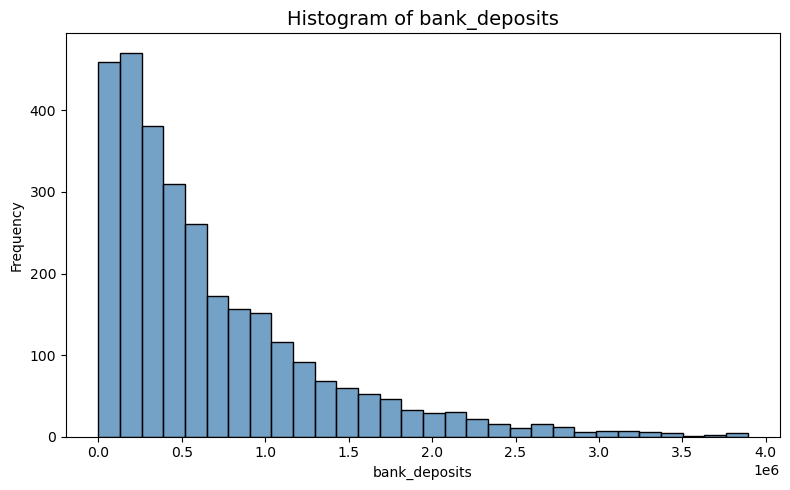

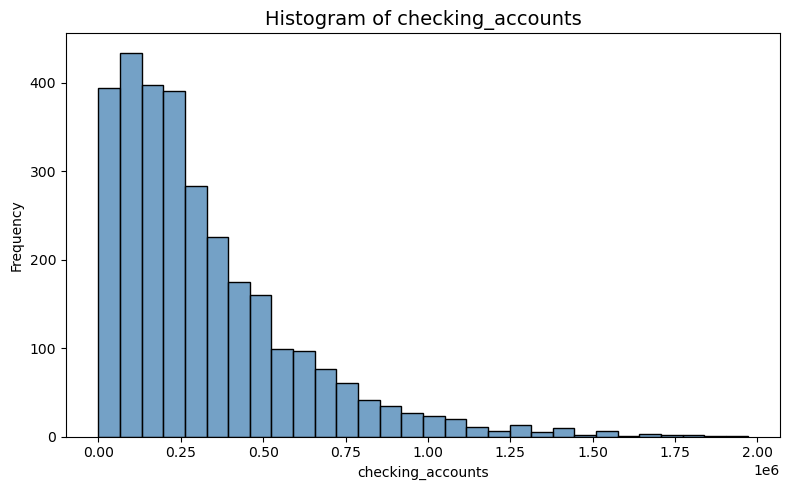

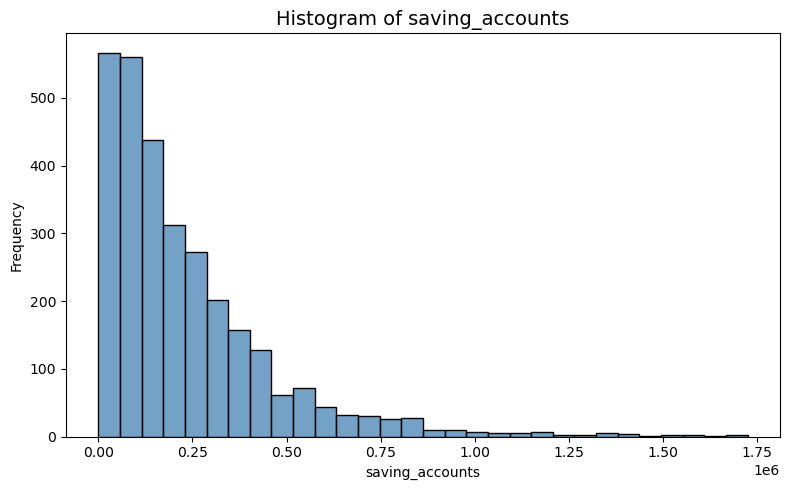

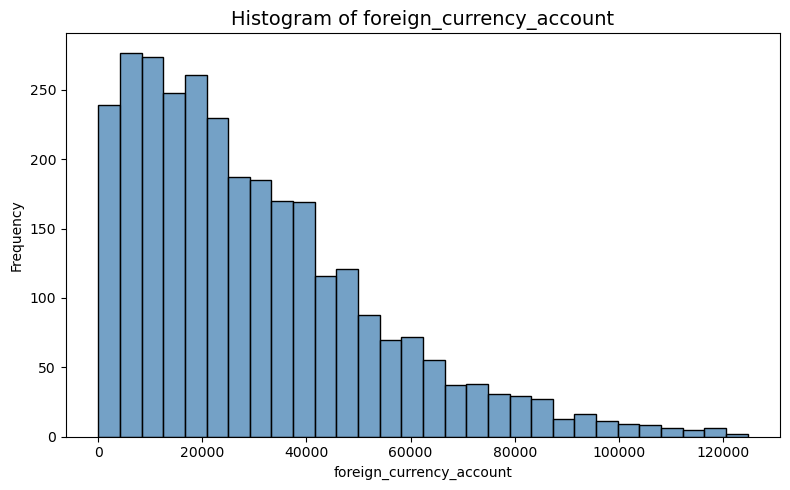

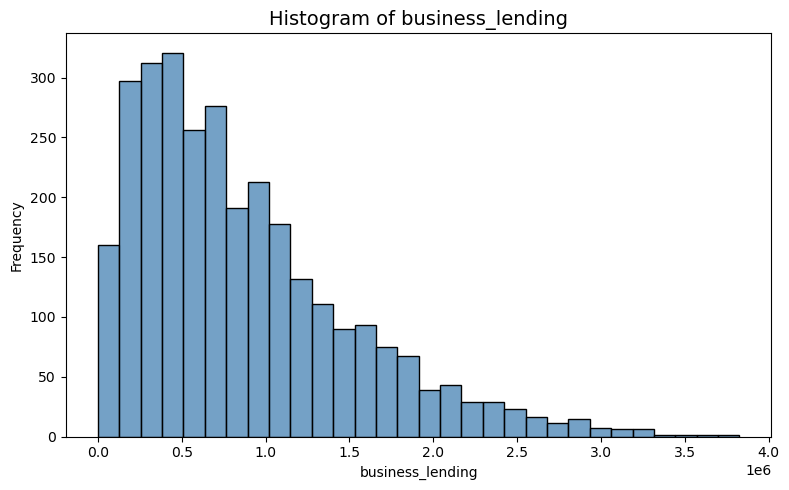

In [19]:
num_cols = [
    'estimated_income',
    'superannuation_savings',
    'credit_card_balance',
    'bank_loans',
    'bank_deposits',
    'checking_accounts',
    'saving_accounts',
    'foreign_currency_account',
    'business_lending'
]

for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=False,
        color='steelblue',
        edgecolor='black'
    )

    plt.title(f'Histogram of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

## Bivariate Analysis

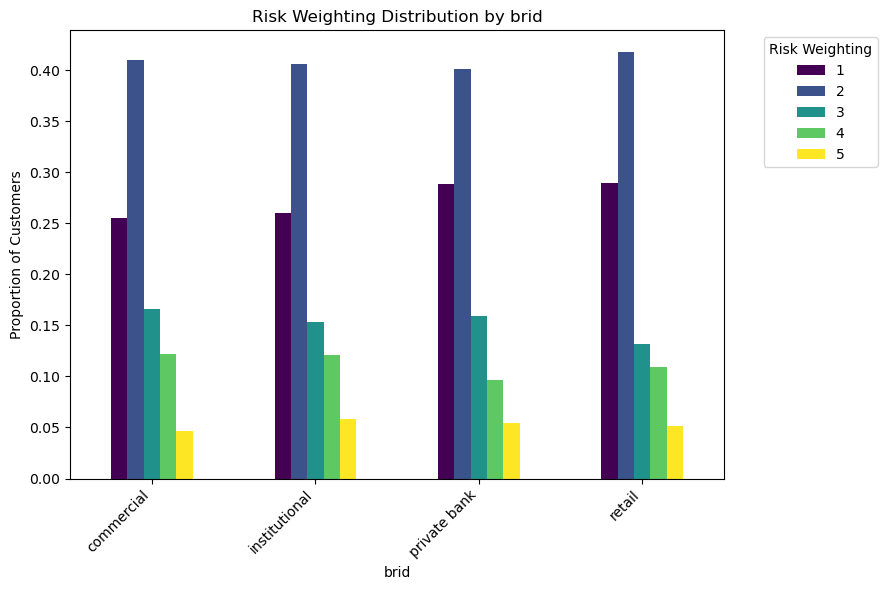

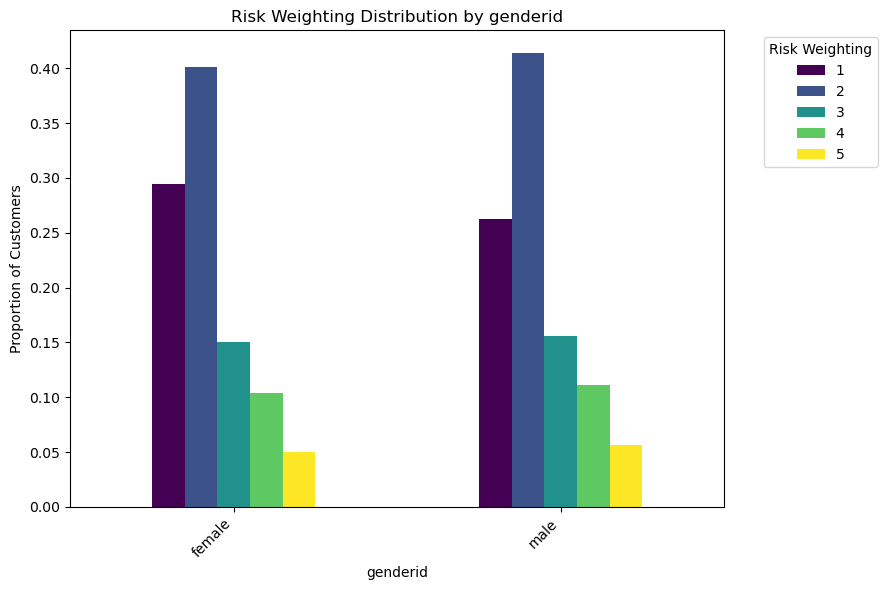

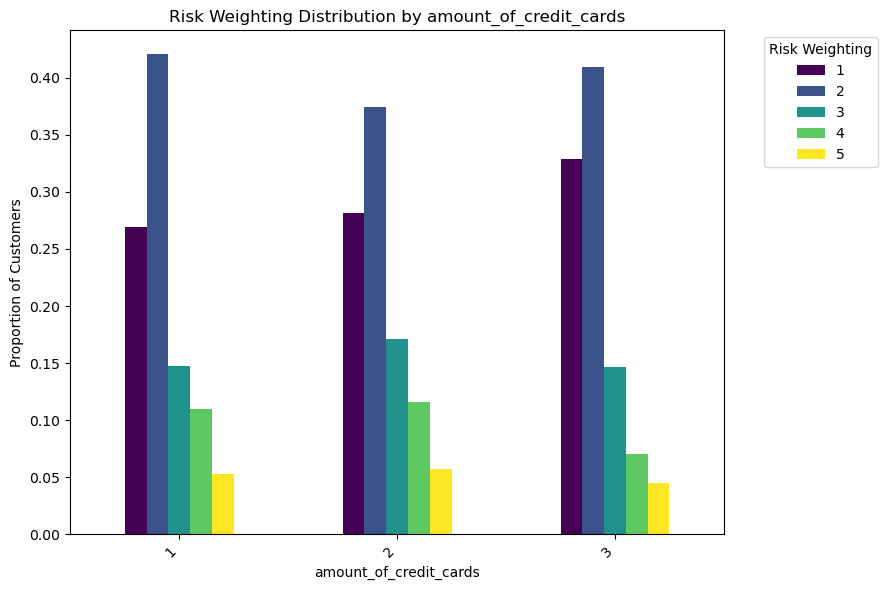

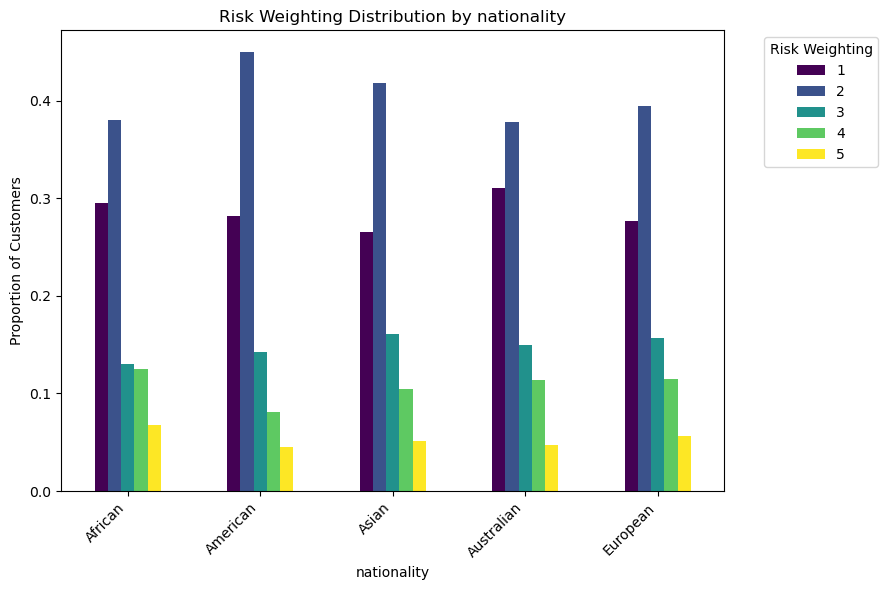

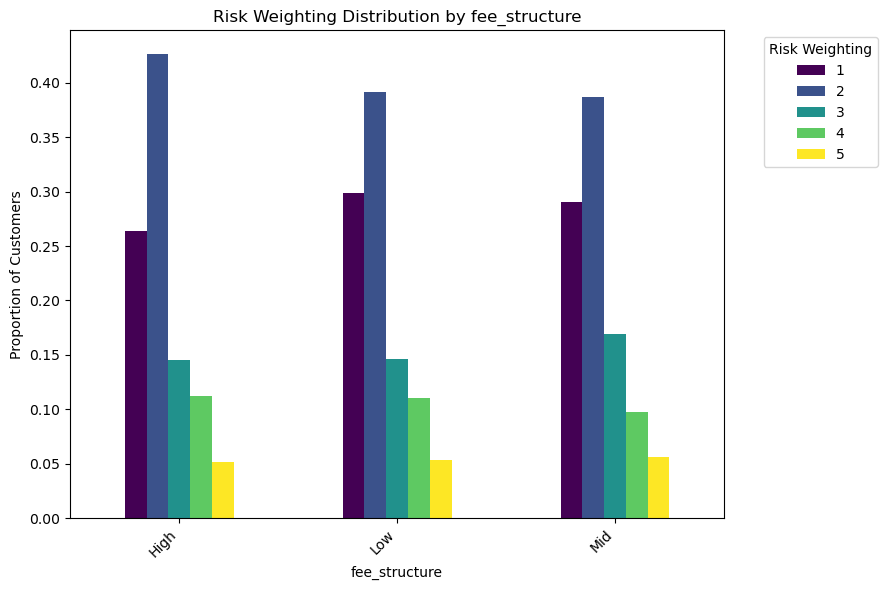

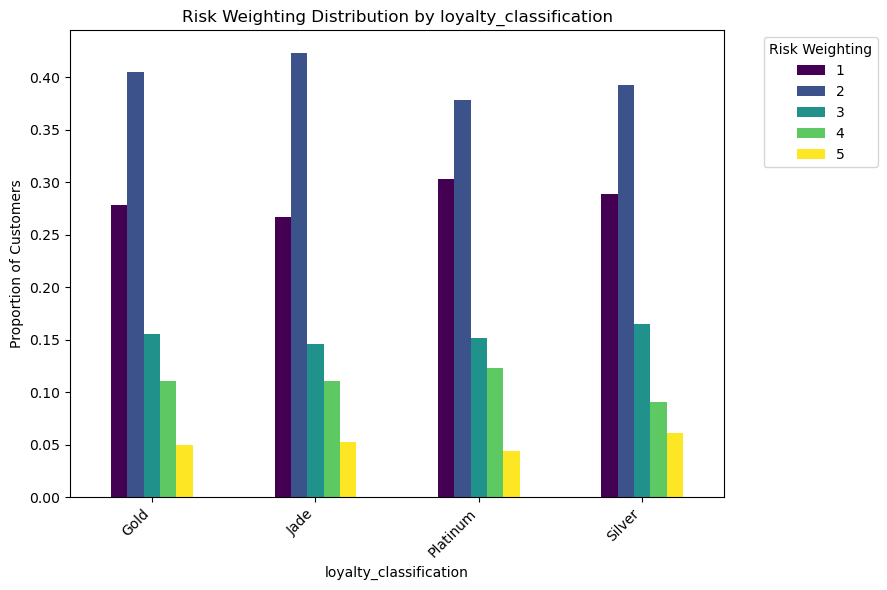

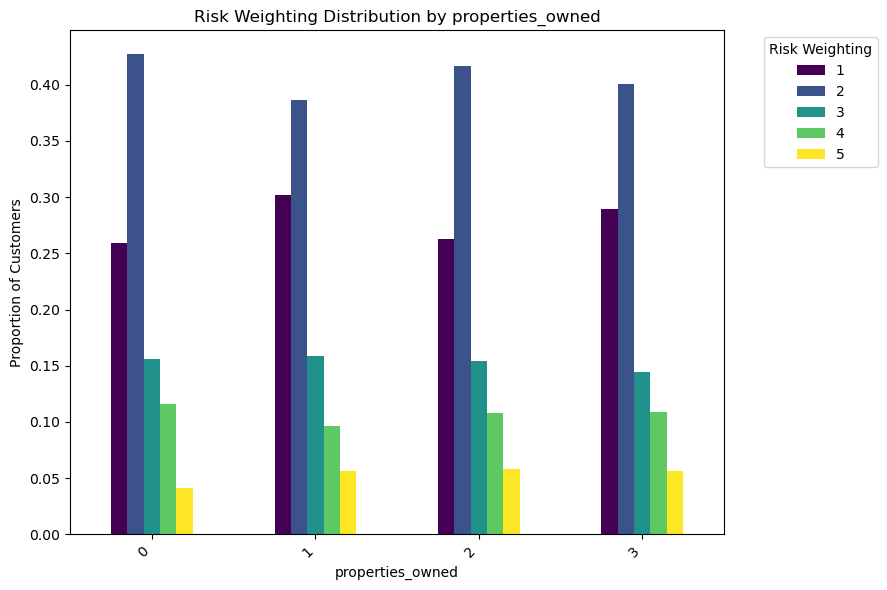

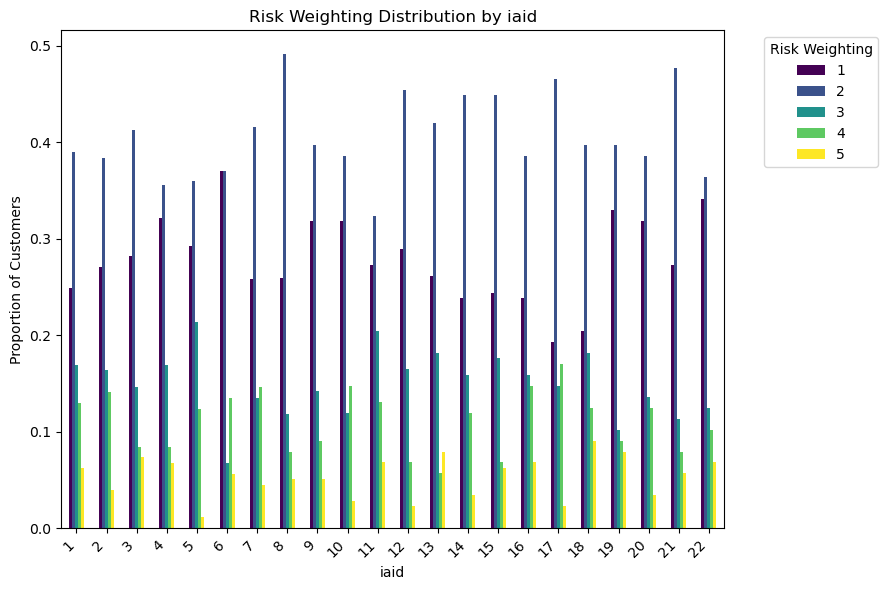

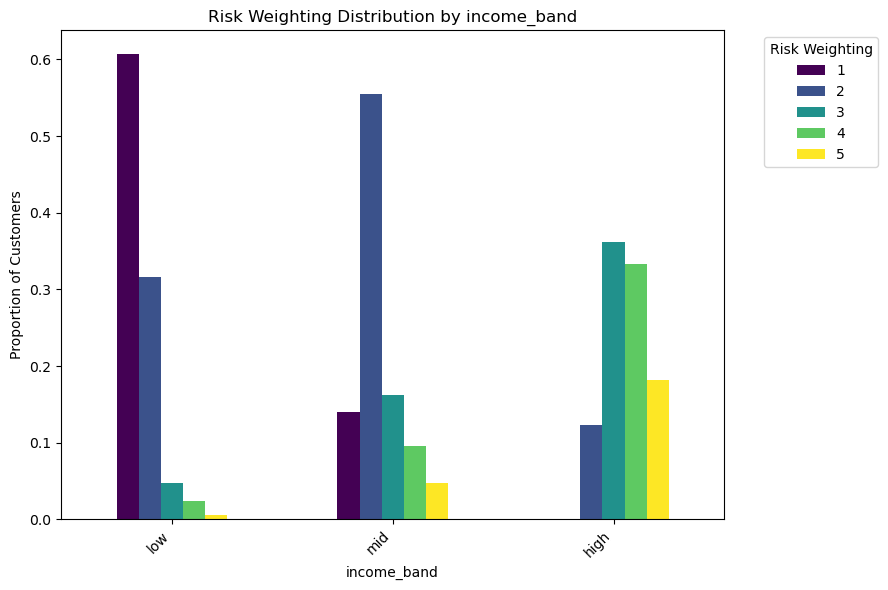

In [20]:
cats_cols = ['brid', 'genderid', 'amount_of_credit_cards', 'nationality',
             'fee_structure', 'loyalty_classification',
             'properties_owned', 'iaid', 'income_band']  # removed risk_weighting since it's the target

for col in cats_cols:
    ct = pd.crosstab(df_new[col], df_new['risk_weighting'], normalize='index')  # proportions per row
    ct.plot(kind='bar', stacked=False, figsize=(9,6), colormap='viridis')
    plt.title(f'Risk Weighting Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion of Customers')
    plt.legend(title='Risk Weighting', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

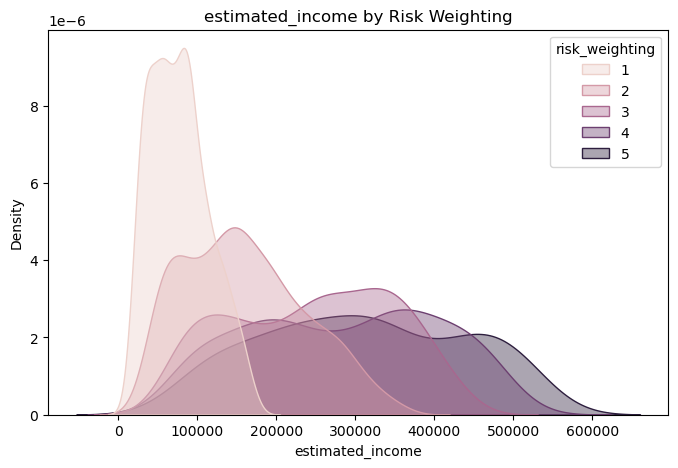

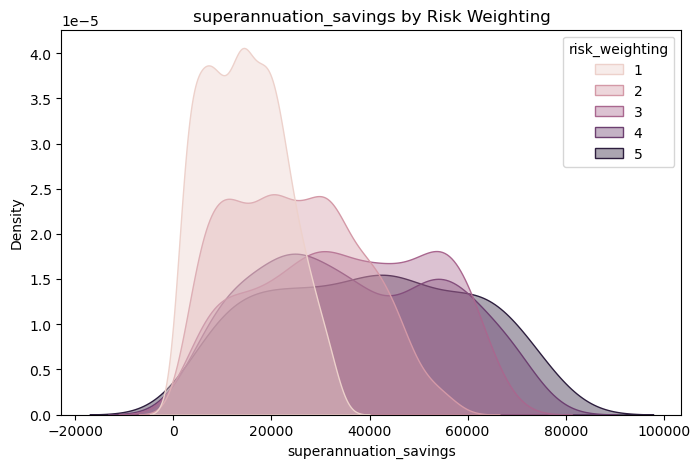

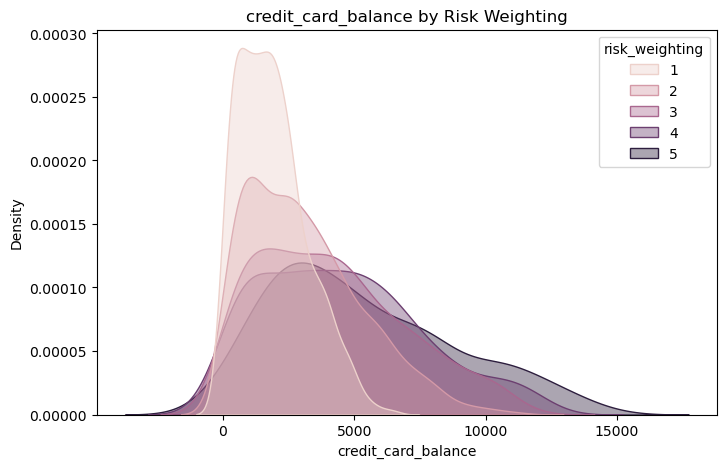

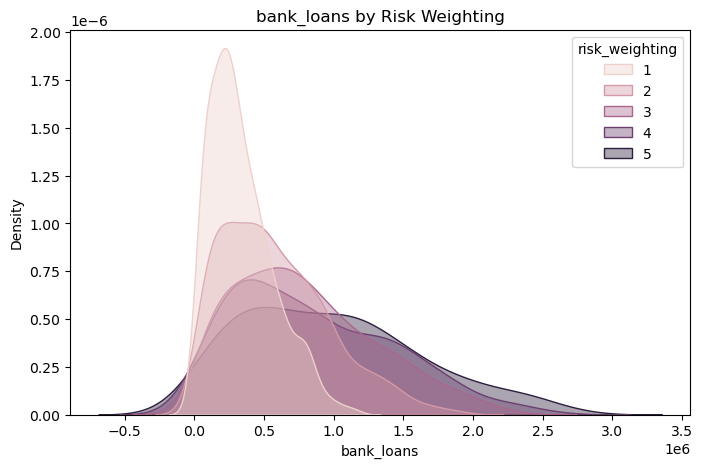

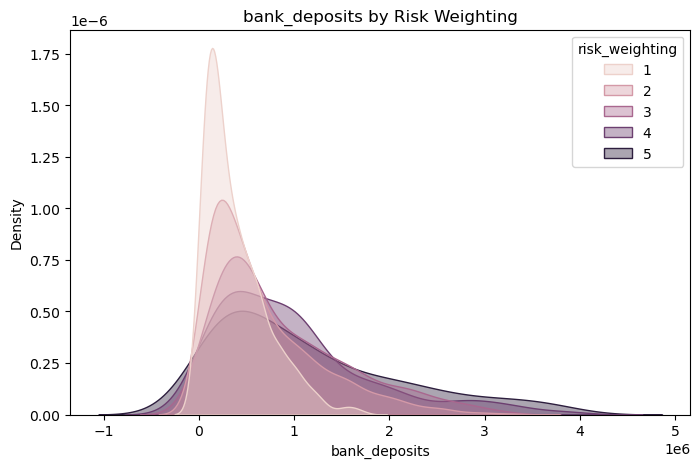

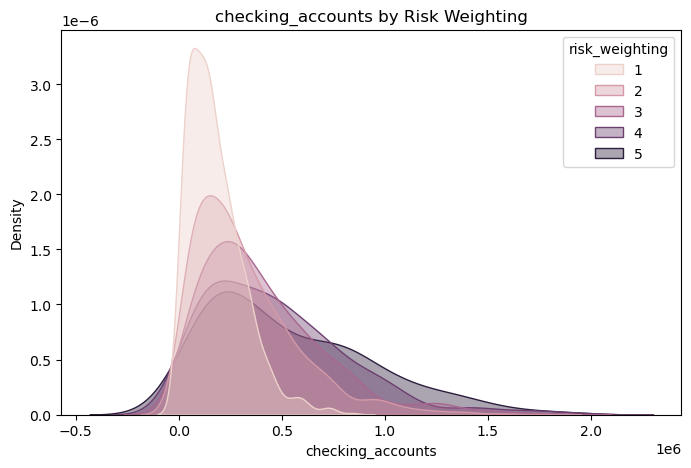

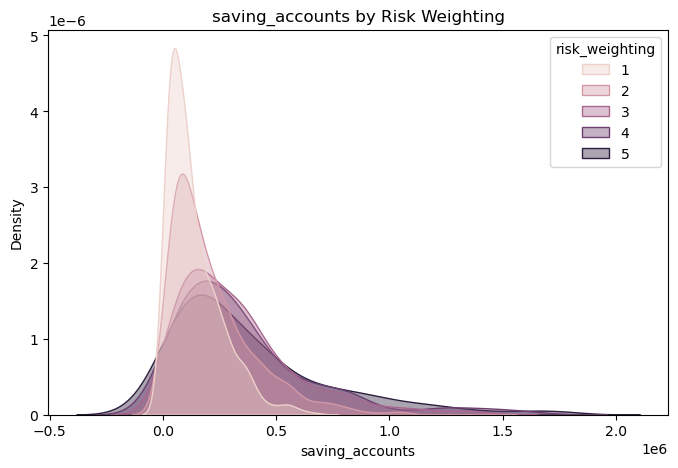

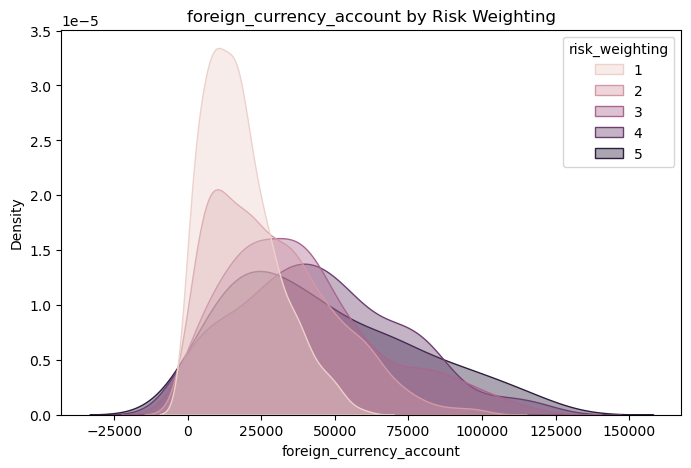

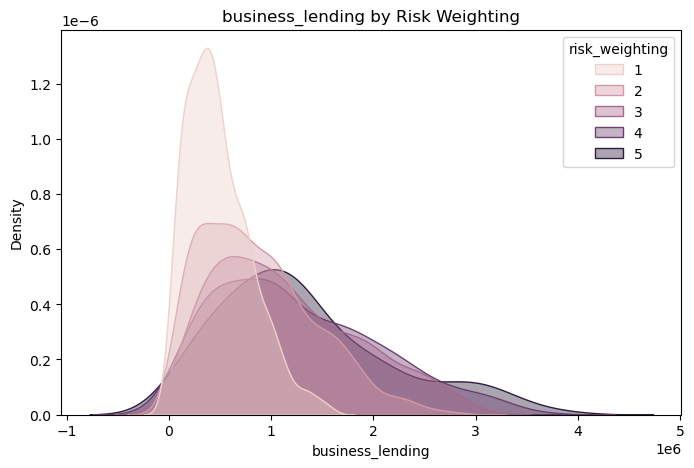

In [21]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=df,
        x=col,
        hue='risk_weighting',
        fill=True,
        common_norm=False,
        alpha=0.4
    )

    plt.title(f'{col} by Risk Weighting')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

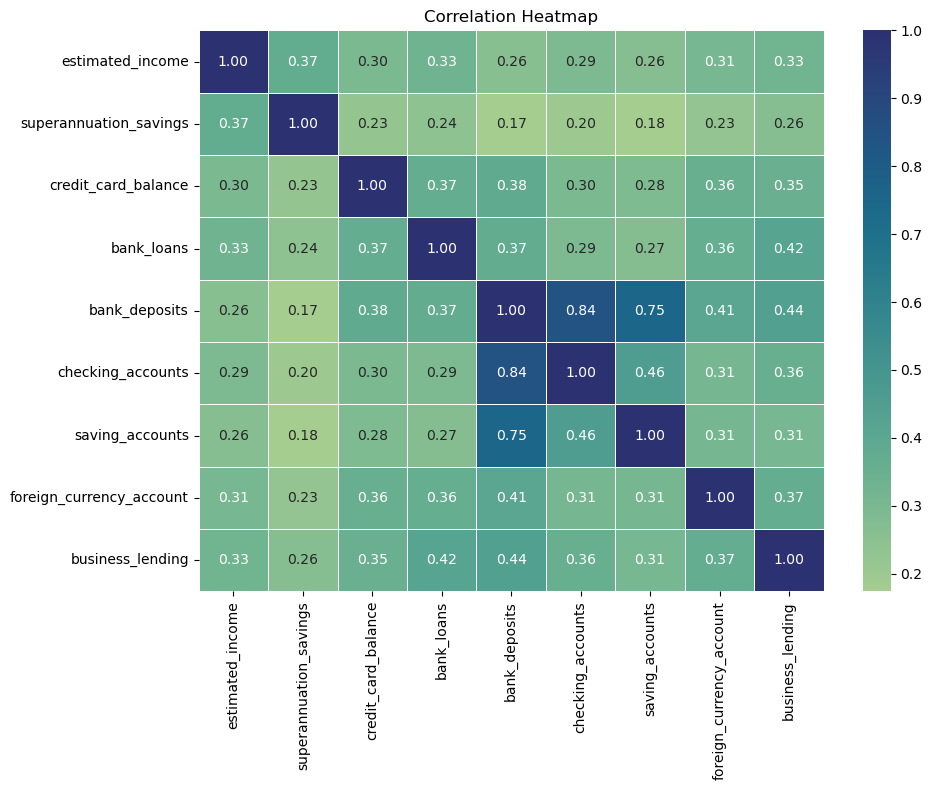

In [22]:
# Correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='crest',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [23]:
df_new.to_csv('Banking_new')

## Insights

Bank deposits show a strong positive correlation with both checking accounts and saving accounts. This indicates that customers maintaining higher balances in their checking and savings accounts also tend to have higher total bank deposits. The relationship is expected, as checking and savings balances likely contribute significantly to a customer's overall deposits with the bank.

In [24]:
df_new['client_id'].nunique()

2940